In [ ]:
import yfinance as yf
import pandas as pd
import os

# 1. Configurações de Caminho e Ticker
ticker = "GC=F"
start_date = "2020-10-01"
output_dir = "/home/brown/Documents/macro_fred/fred/data/01_raw/yfinance"
output_file = os.path.join(output_dir, "gold.parquet")

# Criar o diretório caso ele não exista
os.makedirs(output_dir, exist_ok=True)

print(f"Iniciando extração do {ticker}...")

# 2. Download dos dados
# auto_adjust=True já traz o fechamento ajustado na coluna 'Close'
df = yf.download(ticker, start=start_date, auto_adjust=True)

if not df.empty:
    # 3. Tratamento para garantir que o Parquet aceite os dados
    # Achatando MultiIndex se necessário
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    
    # Resetando o índice para que a data vire uma coluna comum
    df = df.reset_index()
    
    # Padronizando nomes de colunas (bom para integração com sua IA futura)
    df.columns = [col.lower().replace(' ', '_') for col in df.columns]
    
    # 4. Salvando em formato Parquet
    try:
        df.to_parquet(output_file, index=False, engine='pyarrow')
        print(f"✅ Sucesso! Ouro salvo em: {output_file}")
        print(f"📊 Total de linhas: {len(df)}")
    except Exception as e:
        print(f"❌ Erro ao salvar Parquet: {e}")
else:
    print("❌ O yfinance retornou um DataFrame vazio.")

# Exibir prévia
df.head()

[*********************100%***********************]  1 of 1 completed


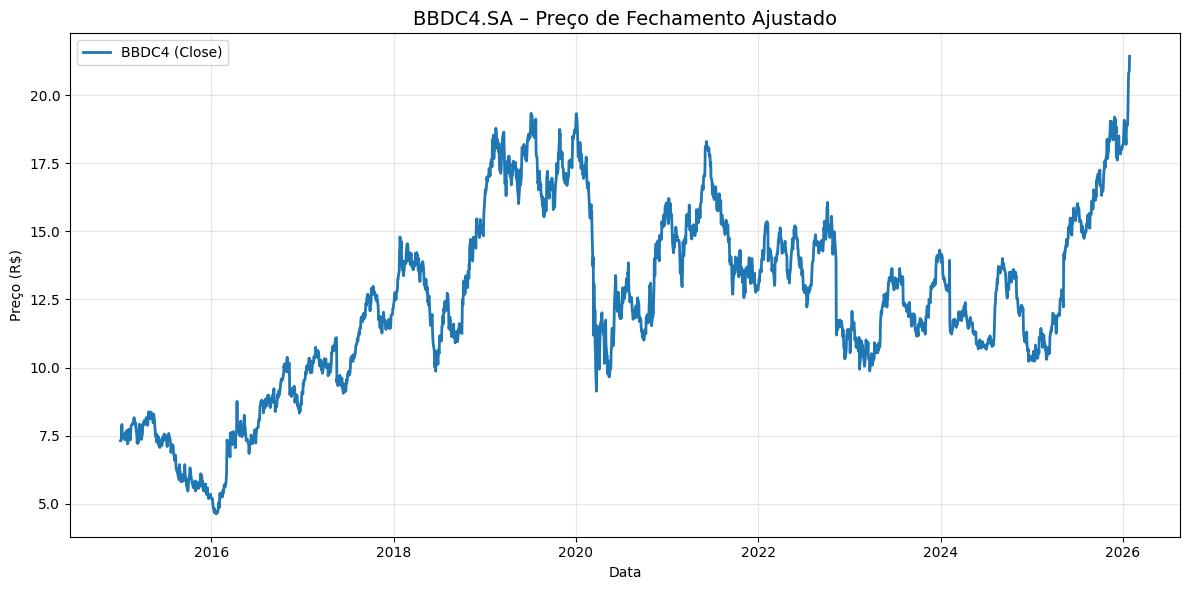

In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Configurações
# -----------------------------
ticker = "BBDC4.SA"
start_date = "2015-01-01"

# -----------------------------
# Download dos dados
# -----------------------------
df = yf.download(
    ticker,
    start=start_date,
    auto_adjust=True,
    progress=False,
    threads=False,  # evita paralelismo interno
)

if df.empty:
    raise ValueError("Nenhum dado retornado pelo yfinance.")

# -----------------------------
# Tratamento básico
# -----------------------------
df = df.reset_index()
df["Date"] = pd.to_datetime(df["Date"])

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], label="BBDC4 (Close)", linewidth=2)

plt.title("BBDC4.SA – Preço de Fechamento Ajustado", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Preço (R$)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


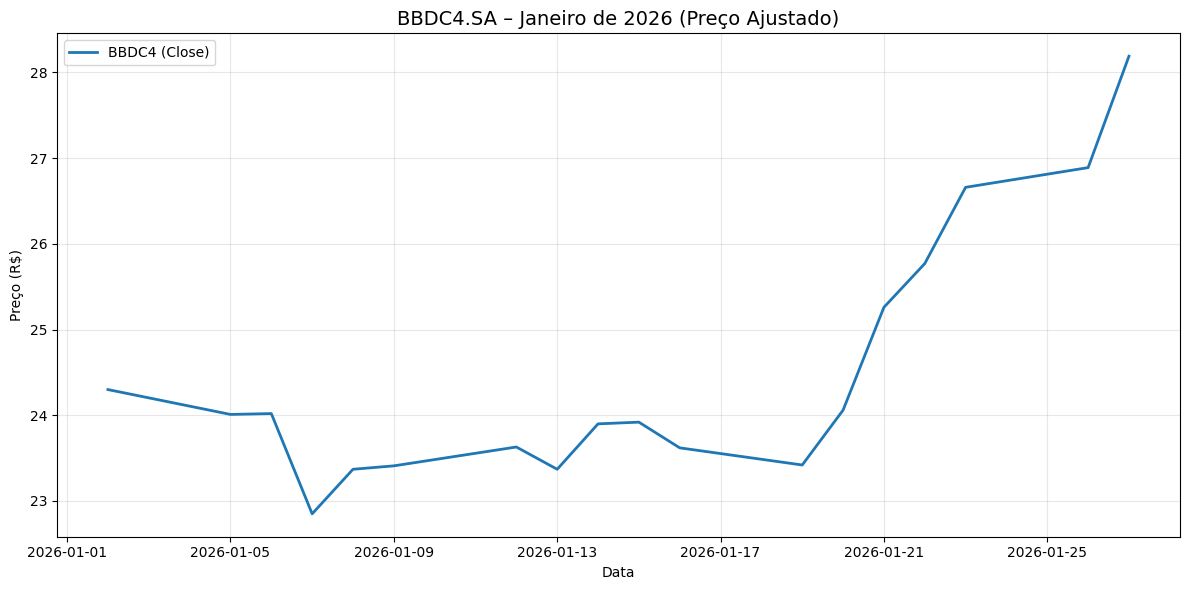

In [3]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

# -----------------------------
# Configurações
# -----------------------------
ticker = "CYRE4.SA"
start_date = "2026-01-01"
end_date = "2026-02-01"  # limite exclusivo

# -----------------------------
# Download dos dados
# -----------------------------
df = yf.download(
    ticker,
    start=start_date,
    end=end_date,
    auto_adjust=True,
    progress=False,
    threads=False,
)

if df.empty:
    raise ValueError("Nenhum dado retornado pelo yfinance para Jan/2026.")

# -----------------------------
# Tratamento básico
# -----------------------------
df = df.reset_index()
df["Date"] = pd.to_datetime(df["Date"])

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(12, 6))
plt.plot(df["Date"], df["Close"], label="BBDC4 (Close)", linewidth=2)

plt.title("BBDC4.SA – Janeiro de 2026 (Preço Ajustado)", fontsize=14)
plt.xlabel("Data")
plt.ylabel("Preço (R$)")
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()
